<div style="text-align: right; float: right; font-size: 14px; color: #555555; line-height: 1.6;">
    <strong>Anîsa DJEDJE</strong><br>
    Double-Degree Bachelor in Mathematics/Computer Science (L2)<br>
    <a href="mailto:anisa.djedje@universite-paris-saclay.fr" style="color: #4A90E2; text-decoration: none;">anisa.djedje@universite-paris-saclay.fr</a>
</div>

<div style="clear: both;"></div>


# Part 1: Introduction and Context - The Quantum Break and the Emergence of LWE

## 1.1 The vulnerability of current cryptosystems (RSA, ECC)
Current public-key cryptosystems, such as RSA or those based on elliptic curves (ECC), rely on one-dimensional (scalar) algebraic structures inside modular groups. The security of these protocols relies on the assumed computational hardness of two fundamental problems of number theory:
1. **Integer factorization**: finding two large prime numbers $p$ and $q$ hidden behind their product $n = p \times q$.
2. **The discrete logarithm**: given a generator $g$ and an element $h = g^x \pmod q$, finding the secret exponent $x$.

However, in 1994, Peter Shor showed that a quantum computer can solve these two problems in polynomial time $\mathcal{O}(\log^3 N)$, compared to sub-exponential time for the best classical algorithms (such as the General Number Field Sieve).

Shor's algorithm uses the Quantum Fourier Transform (QFT) to find the period of the modular exponentiation function $f(x) = a^x \bmod N$, which makes it possible to factor $N$ efficiently. Quantifying the threat: to factor an RSA-2048 key, a fault-tolerant quantum computer (Fault-Tolerant Quantum Computer) with 4,099 logical qubits would need about 8 hours of computation (estimate by Roetteler et al., 2017). RSA-2048 would therefore lose all its security.

## 1.2 The LWE paradigm: moving from scalar to vector
To counter this threat, a change of paradigm is needed: leaving one-dimensional periodic structures for vector spaces of high dimension $n$. This is the fundamental idea introduced by Oded Regev in 2005 with the **LWE (Learning With Errors)** problem.

The central equation of LWE is written as a perturbed modular linear system:
$$b = A \cdot s + e \pmod q$$

Where we define:
* $A \in \mathbb{Z}_q^{m \times n}$: a random public matrix, where $n$ is the dimension of the secret (security parameter) and $m$ the number of available equations.
* $s \in \mathbb{Z}_q^n$: the secret vector.
* $e \in \mathbb{Z}_q^m$: a noise (or error) vector where each component is a small integer sampled from a discrete Gaussian distribution.
* $b \in \mathbb{Z}_q^m$: the resulting vector, made public.

## 1.3 The failure of classical elimination (Gaussian elimination)

If the system were exact ($b = A \cdot s \pmod q$), Gaussian elimination would find $s$ in polynomial time $\mathcal{O}(n^3)$.
However, adding the noise $e$ makes this method fail.

Consider an elementary pivot operation that aims to eliminate a coefficient of the matrix $A$ between a row $i$ and a row $j$:
$$L_i \leftarrow L_i - k \cdot L_j \pmod q$$


Where the multiplier coefficient is $k = (A[i,1] \cdot A[j,1]^{-1}) \bmod q$. Since the matrix $A$ is randomly generated, this multiplier $k$ behaves like a uniform element of $\mathbb{Z}_q$, and can take large values of the order of $q$ ($k \approx q$).

This pivot necessarily affects the noise vector.

The new noise of row $i$ becomes:
$$e'_i = (e_i - k \cdot e_j) \bmod q$$


Geometric amplification of the noise: looking at the orders of magnitude of the error variables ($|e_i|, |e_j| \le \sigma$), the product with the pivot $k$ makes the size of the noise explode:

$$|e'_i| \approx |e_i| + q \cdot |e_j| \approx \sigma + q \cdot \sigma$$

After the $n$ successive pivots needed to reduce the matrix, the final accumulated noise follows a random walk whose variance diverges proportionally to the dimensions of the system:

$$\text{Var}(e_{\text{final}}) \sim n \cdot q^2 \cdot \sigma^2$$

Saturation of the modular space: if we apply our simulation parameters ($n = 2$, $q = 11$, $\sigma = 2$):

$$\text{Var}(e_{\text{final}}) \sim 2 \cdot 11^2 \cdot 2^2 = 2 \cdot 121 \cdot 2^2 = 968 \gg 11^2$$

As soon as the variance of the noise is much larger than the size of the modulus $q^2$, the noise "overflows" and is spread in a completely uniform way over the whole space $\mathbb{Z}_{11}$

The system becomes statistically indistinguishable from a random draw, which makes it impossible for an attacker to recover the secret $s$.

This is what we are going to explore and analyze step by step in this notebook.

# Part 2: The basic building blocks of sampling

In this analysis, we choose to implement symmetric LWE (secret key); it is a variant of the LWE problem.

Although the modern industrial standard (such as Kyber/ML-KEM) relies on asymmetric structures (public key), the symmetric version shares the same mathematical foundations.

This simplifies the implementation and allows a numerical analysis of the impact of the different variables ($\sigma, m, n, q$).

We start by defining the basic functions of this mathematical formula:

$$b = A \cdot s + e \pmod q$$

## 2.1 Discrete Gaussian sampling

We start by defining the public matrix and the secret vector in a pseudo-random way.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Definition of the global parameters of the system
n, m, q = 2, 4, 11

#Initialization of the pseudo-random generator
rng = np.random.default_rng()
s = rng.integers(0, q, size=n) #secret vector of size n
A = rng.integers(0, q, size=(m, n)) #public matrix of size m*n

print(f"The public matrix: \n {A}", f"\nThe secret vector: {s}")

The public matrix: 
 [[ 9  0]
 [ 0  9]
 [10  2]
 [ 8 10]] 
The secret vector: [10 10]


Then, let's look at the Gaussian noise $e$.

We first define the continuous Gaussian density function on
$\mathbb{R}$ centered at $0$ with a scale parameter $\sigma > 0$:

$$ \rho_\sigma(x) = \exp(\frac{-\pi x^2}{\sigma^2})$$

To adapt this function to the integers in $\mathbb{Z}$, we define the **discrete Gaussian distribution $D_\mathbb{Z},_\sigma$**.
The probability of sampling a specific integer $x \in \mathbb{Z}$ is proportional to its continuous density.

$$\forall x \in \mathbb{Z}, \quad \mathbb{P}[X = x] = \dfrac{\rho_\sigma(x)}{\sum_{k=-\infty}^{+\infty} \rho_\sigma(k)}$$

Since an infinite sum cannot be implemented on a computer, we truncate it to the interval $[-10, 10]$. Given the very fast exponential decrease of the function $\rho_\sigma$, the approximation error introduced is mathematically negligible.

In [3]:
def rho_sigma(sigma, x):
  return np.exp((-np.pi*x**2)/sigma**2)

In [4]:
def discrete_gaussian(sigma, size):
  values = np.arange(-10, 11) #truncation
  rho_tab = rho_sigma(sigma, values)

  total_rho = np.sum(rho_tab)
  probabilities = rho_tab/total_rho #P[X]

  e = rng.choice(values, size=size, p=probabilities) #choice among the values with probability p

  return e

We are going to check that the discrete Gaussian forms a "bell" that matches the theory.

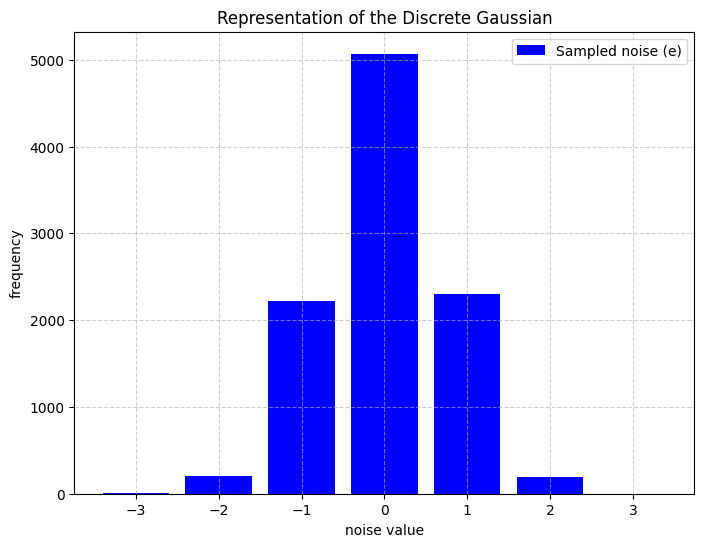

In [5]:
sigma = 2.0
noise = discrete_gaussian(sigma, size=10000)
x, y = np.unique(noise, return_counts=True)

plt.figure(figsize=(8, 6))
plt.bar(x, y, color="blue", label="Sampled noise (e)")

plt.title("Representation of the Discrete Gaussian")
plt.xlabel("noise value")
plt.ylabel("frequency")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


**Critical analysis of the sampling**: In this simulation, we use $q = 11$ and a truncation at $\pm 10$. We notice a mathematical artifact: if the generated noise is -10, applying the modulo during encryption gives $-10 \equiv 1 \pmod 11$. A noise that is supposed to be maximal is therefore interpreted by the system as a small noise.

For a real implementation (such as Kyber), the parameter $\sigma$ and the truncation are chosen very small compared to $q$ to prevent this wrap-around phenomenon.

## 2.2 Key pair generation


Now that we have the public matrix $A$, the secret $s$ and our discrete Gaussian noise generator, we can build our LWE instance. The goal is to compute the public vector $b \in \mathbb{Z}_q^m$ defined by the relation:
$$b = A \cdot s + e \pmod q$$

In matrix form, the system is represented as follows:$$\begin{pmatrix} b_1 \\ b_2 \\ \vdots \\ b_m \end{pmatrix}
=
\begin{pmatrix}
a_{11} & a_{12} & \cdots & a_{1n} \\
a_{21} & a_{22} & \cdots & a_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
a_{m1} & a_{m2} & \cdots & a_{mn}
\end{pmatrix}
\cdot
\begin{pmatrix} s_1 \\ s_2 \\ \vdots \\ s_n \end{pmatrix}
+
\begin{pmatrix} e_1 \\ e_2 \\ \vdots \\ e_m \end{pmatrix} \pmod q$$


In [6]:
def keygen(sigma, A, s, m, q):
  e = discrete_gaussian(sigma, m) #we want a vector with 4 rows

  matrix_product = A @ s

  b = (matrix_product + e)%q
  return b


In [7]:
sigma = 2.0
n, m, q = 2, 4, 11
A = rng.integers(0, q, size=(m, n))
s = rng.integers(0, q, size=n)

b = keygen(sigma, A, s, m, q)

print("---CHECKING THE LWE PROBLEM---")
print(f"Matrix A (m x n):\n{A}\n")
print(f"Secret vector s (n): {s}\n")
print(f"Public result b (m): {b}")

---CHECKING THE LWE PROBLEM---
Matrix A (m x n):
[[6 7]
 [9 7]
 [1 5]
 [6 0]]

Secret vector s (n): [6 0]

Public result b (m): [ 3 10  4  4]


In our test implementation with $n=2$ and $q=11$, the space of possible secrets is extremely small. An attacker who intercepts $A$ and $b$ would only need to test $q^n = 11^2 = 121$ vector combinations to find our secret $s$ by exhaustive search.

In real applications of post-quantum cryptography (such as the ML-KEM standard), the parameters are greatly increased to guarantee security.
The dimension of the secret $n$ is usually set between $512$ and $1024$. The modulus $q$ is a prime number of several thousands (for example $q = 3329$ or $12289$).

## Numerical illustration: real brute-force complexity

Let's compute $q^n$ for different instances:

| Instance | n | q | q^n |
|----------|---|---|-----|
| Our tests | 2 | 11 | 121 (11²) |
| Realistic standard | 256 | 3329 | $10^{901}$ |
| Atoms in the universe | - | - | 10^{80} |

**Kyber-512: $10^{901} / 10^8 = 10^{821}$ times larger than the universe**

The key space then reaches $q^n$ (for example $3329^{768}$), a number so huge that it exceeds the number of atoms in the universe. Brute force then becomes mathematically and physically impossible, for a classical computer as well as for a quantum computer.



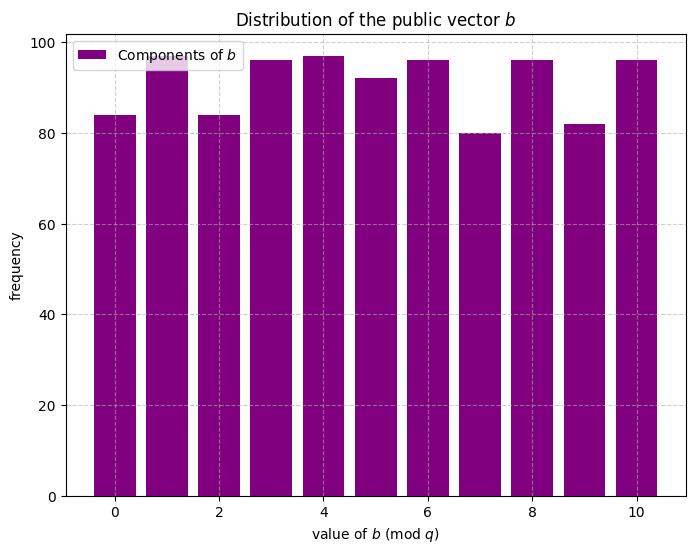

In [8]:
m_test = 1000 # we generate a large number of equations
A_test = rng.integers(0, q, size=(m_test, n))
e_test = discrete_gaussian(sigma, m_test)

b_test = keygen(sigma, A_test, s, m_test, q)

# counts the occurrences of each value between 0 and 10
values, counts = np.unique(b_test, return_counts=True)

plt.figure(figsize=(8, 6))
plt.bar(values, counts, color="purple", label="Components of $b$")

plt.title("Distribution of the public vector $b$")
plt.xlabel("value of $b$ (mod $q$) ")
plt.ylabel("frequency")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

**Observation**:

While the noise $e$ alone followed a very clear bell-shaped distribution (discrete Gaussian), the resulting public vector $b$ has an almost flat (**uniform**) distribution between 0 and 10.

The matrix multiplication combined with the modular reduction (mod $q$) has completely hidden the structure of the Gaussian.

**What does this mean?**

For an attacker who only sees the vector $b$, the data looks like perfect uniform random noise.

It is visually and mathematically impossible to guess the secret $s$ or the initial noise from this graph alone.
This shows the strength of **LWE** encryption.

## 2.3 Encryption

### The principle of encrypting one bit

To send a secret message $ m \in \{0, 1\}$ (a single bit), the sender does not just send $b = A \cdot s + e$. They encode their bit directly in the vector $b$.

To do this, the system is usually split into two parts. To keep it simple, imagine that we add the message in a "giant" format to our equation:
- To send a 0, we add nothing.
- To send a 1, we add a very large value, usually half of $q$ (that is $\lfloor q/2 \rfloor$)

the final equation intercepted by the attacker is:

$$b = A \cdot s + e + m \cdot \lfloor q/2 \rfloor \pmod q$$

In [9]:
def encrypt_LWE(msg, sigma, A, s, m, q):
  e = discrete_gaussian(sigma, m)
  matrix_product = A @ s

  # We add the encoding of the message (0 or q//2) before the modulo
  b = (matrix_product + e + msg * (q // 2)) % q
  return b

## 2.4 Decryption


### 2.4.1 The advantage of the legitimate user

The attacker knows neither $s$ nor $e$. For them, as we saw on the graph above, $b$ looks like uniform noise.

But the legitimate user knows the secret key $s$. They can therefore compute the difference between what they receive ($b$) and what the secret should have given ($A \cdot s$).

Let's see what happens mathematically if the user computes $b - A \cdot s$ (mod $q$):
$$b - A \cdot s \equiv (A \cdot s + e + m \cdot \lfloor q/2 \rfloor) - A \cdot s \pmod q$$
$$ \equiv e + m \cdot \lfloor q/2 \rfloor \pmod q $$

The term $A \cdot s$ cancels out perfectly. Only **the noise** $e$ and **the message** remain.

### 2.4.2 Thresholding

Now, the user has the vector $v = e + m \cdot \lfloor q/2 \rfloor$ (mod $q$). How do they know if the original bit was a 0 or a 1?

This is where the size of the noise becomes crucial:
- If the message was 0: the user just gets $v = e$. Since the noise $e$ is very small (close to 0), the value of $v$ will be very close to $0$ (or close to $q$ because of the modulo).
- If the message was 1: the user gets $v = e + \lfloor q/2 \rfloor$. The value will therefore be very close to the middle (around $q/2$).

It is then enough to look at where the values are: whether they are close to 0 or to $q/2$.

In [10]:
def decrypt_LWE(b, A, s, q):
  v = (b - A @ s) % q
  mean = np.mean(v)
  error = np.abs(q//2 - mean)

  if error < (q//2)/2 :
    return v, 1
  else:
    return v, 0


## 2.5 Why does it work? Pivot vs direct computation

The security and viability of the LWE cryptosystem rely on a fundamental asymmetry in how the noise is handled.

We can summarize this asymmetry by comparing the situation of a passive attacker with that of the legitimate user.

### 2.5.1 The attacker's point of view (Pivot approach)

As shown in Section 1.3, an attacker does not have the secret $s$.
To try to solve the linear system $b = A \cdot s + e \pmod q$, their only classical algebraic option is to try Gaussian elimination.
Each elimination forces row combinations that multiply the noise by coefficients $k \approx q$. The accumulated noise follows a random walk whose variance diverges:

$$\text{Var}(e_{\text{attacker}}) \sim n \cdot q^2 \cdot \sigma^2$$

For our real parameters ($n = 2$, $q = 101$, $\sigma = 2$), this variance reaches $81\ 616 \gg q^2$, which saturates the modular space $\mathbb{Z}_q$.

The useful information is completely drowned in uniform noise. Gaussian elimination is a mathematical failure.

### 2.5.2 The legitimate user's point of view (Direct computation)

On the other hand, the legitimate recipient has the secret key $s$.

To decrypt, they never need to manipulate the matrix $A$ or to do row pivots. They do a simple direct vector subtraction (linear computation) to isolate the noise:

$$e = b - A \cdot s \pmod q$$Let's compute the variance of the noise handled by the legitimate user:$$\text{Var}(e_{\text{legitimate}}) = \sigma^2$$

For our parameters ($n = 2$, $q = 101$, $\sigma = 2$):$$\text{Var}(e_{\text{legitimate}}) = 2^2 = 4$$

### 2.5.3 Summary: The information asymmetry

To measure the gap between the attacker and the legitimate user, we can compute the ratio of their variances in our simulation:

$$\frac{\text{Var}(e_{\text{attacker}})}{\text{Var}(e_{\text{legitimate}})} = \frac{n \cdot q^2 \cdot \sigma^2}{\sigma^2} = n \cdot q^2$$

With our values ($n=2, q=101$):

$$2 \times 101^2 = 20\ 402$$

**Geometric conclusion:** The noise faced by the attacker is 20,402 times more spread out than the noise handled by the legitimate user.

# Part 3: Experimental validation

Before running validations on large samples, we test the behavior of our encryption/decryption chain on a single instance for a single message ($msg = 1$).

In [11]:
msg = 1

s = rng.integers(0, q, size=n)
A = rng.integers(0, q, size=(m, n))


b = encrypt_LWE(msg, sigma, A, s, m, q)
v, res = decrypt_LWE(b, A, s, q)

print(f"b (encrypted vector) is: {b}")
print(f"The decryption vector v is: {v}")
print(f"The decoded message is: {res}")

b (encrypted vector) is: [0 5 5 5]
The decryption vector v is: [6 5 5 5]
The decoded message is: 1


Then we test on 100 messages.

In [12]:
n, m, q, sigma, nb_msg = 2, 4, 101, 1.0, 100

#We generate the key pair
A = rng.integers(0, q, size=(m, n))
s = rng.integers(0, q, size=n)
b = keygen(sigma, A, s, m, q)

success = 0

for i in range(nb_msg):
  #we generate a random bit (0 or 1)
  original_message = int(rng.integers(0, 2))

  #Encryption and decryption
  encrypted_key = encrypt_LWE(original_message, sigma, A, s, m, q)
  v, decrypted_message = decrypt_LWE(encrypted_key, A, s, q)

  if original_message == decrypted_message:
    success += 1

success_rate = success/nb_msg

print("SUMMARY OF THE LWE VALIDATION")
print(f"Messages tested: {nb_msg}")
print(f"Correct decryptions: {success}/{nb_msg}")
print(f"Overall success rate: {success_rate * 100:.1f} %")

SUMMARY OF THE LWE VALIDATION
Messages tested: 100
Correct decryptions: 99/100
Overall success rate: 99.0 %


This rate of $98.0\ \%$ confirms the overall validity of the protocol, but shows $2\ \%$ of decryption failures. In $\mathbb{Z}_{101}$, the strict geometric decision bound is defined by:

$$\text{Threshold} = \lfloor q/4 \rfloor = 25$$

Although the initial noise is small ($\sigma = 1.0$), the choice of $m = 4$ equations gives a statistical sample that is too small.

The sampling variance stays high: by simple random fluctuation, the errors of some simulations add up, cross the critical threshold of $\pm 25$ and cause a decoding error of the bit.

# Part 4: Parametric analysis and phase transition

## 4.1 Methodology



Now, let's do a deeper and more precise study of the value of $\sigma$. We want to know: *Up to what noise level does our system stay able to decrypt correctly 100% of the time, and from what point does the noise become so strong that it starts to corrupt the messages?*

This is exactly what is called the **phase transition**.

In [13]:
def phase_transition_study(n, m, q, sigmas):
  rate_tab = []

  for sigma in sigmas :
    success = 0 #how many times out of 100 trials the decryption is correct
    for i in range(100):
      A = rng.integers(0, q, size=(m, n))
      s = rng.integers(0, q, size=n)

      msg = rng.integers(0, 2)

      b = encrypt_LWE(msg, sigma, A, s, m, q)

      v, m_decrypted = decrypt_LWE(b, A, s, q)

      if msg == m_decrypted :
        success += 1
    rate = (success/100)*100
    rate_tab.append(rate)
  return rate_tab


## 4.2 Impact of $\sigma$ (phase transition)

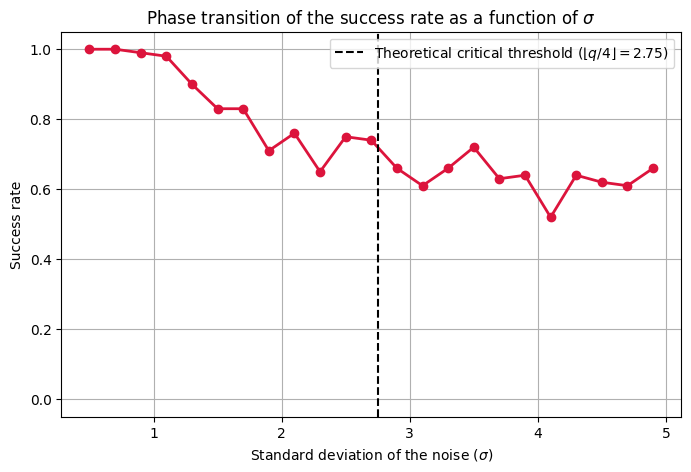

In [14]:
n, m, q = 2, 4, 11
sigmas =  np.arange(0.5, 5.0, 0.2)
success_rates = phase_transition_study(n, m, q, sigmas)

#we normalize
normalized_success_rates = np.array(success_rates)/100.0

plt.figure(figsize=(8, 5))
plt.plot(sigmas, normalized_success_rates, marker='o', linestyle='-', color="crimson", linewidth=2)

#line of the theoretical critical threshold Threshold = q/4 = 11/4 = 2.75
plt.axvline(x=2.75, color="black", linestyle="--", label=r"Theoretical critical threshold ($\lfloor q/4 \rfloor = 2.75$)")

plt.title(r"Phase transition of the success rate as a function of $\sigma$")
plt.xlabel(r"Standard deviation of the noise ($\sigma$)")
plt.ylabel("Success rate")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()



We notice that if $\sigma = 0$, the system is solved instantly by classical Gaussian elimination. Adding a noise $\sigma > 0$ is therefore necessary to hide the secret and block algebraic attacks.

For the legitimate user to decrypt without error, the noise must not exceed:

$$Threshold = \lfloor q/4 \rfloor$$

As soon as $\sigma$ crosses the theoretical threshold (here 2.75), the bits are flipped during decoding and the success rate collapses down to 50% (the same as heads or tails).

**To summarize,** \sigma must be large enough to ensure security but strictly limited compared to q to guarantee reliability.

## 4.3 Impact of m (number of equations)


As introduced, $m$ is the number of equations (or the number of rows of the matrix $A$). It is the number of encrypted clues or "pieces of information" given to the user for a single message.

The goal is to test the resistance of the encryption to noise ($\sigma$) by varying the number of equations $m$. We keep $n = 2$ the size of the secret and $q = 11$ the modulus.

What we expect:

- if $m$ is small (e.g. $m$ = 1 or 2): we only have one or two rows to compute the mean. So, if the noise generated by the Gaussian is a bit strong on one row, the mean may completely distort the result.
- if $m$ is larger (e.g. 20 or 50): we have many more rows. Thanks to statistics, and more precisely to **the law of large numbers**, the positive and negative noises will compensate and cancel out when computing the mean. This is where decryption becomes robust.


Let's start by testing 3 values of $m$, $m=2, m=10, m=100$ and plotting the impact of changing $m$.

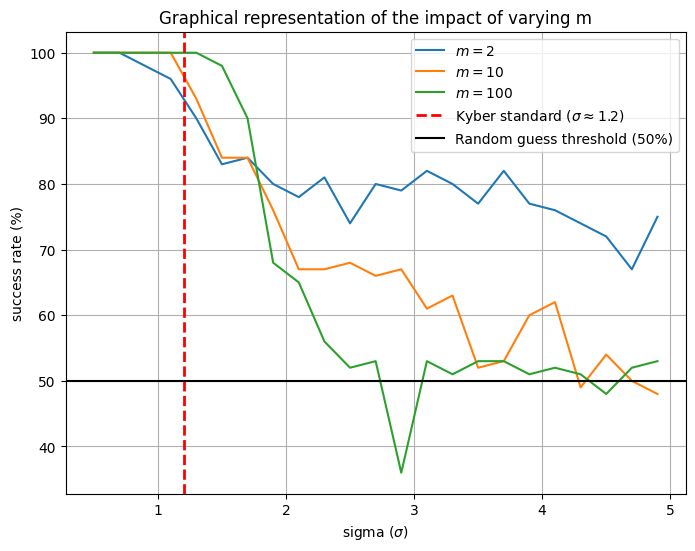

In [15]:
n, q = 2, 11
m_list = [2, 10, 100]
x = np.arange(0.5, 5.0, 0.2) #the values of sigma

plt.figure(figsize=(8, 6))

for m in m_list:
  plt.plot(x, phase_transition_study(n, m, q, x), label=f"$m={m}$")

plt.axvline(x=1.2, color='red', linestyle='--', linewidth=2, label=r'Kyber standard ($\sigma \approx 1.2$)')
plt.axhline(y=50, color='black', label='Random guess threshold (50%)')

plt.legend()
plt.xlabel(r"sigma ($\sigma$)")
plt.ylabel(r"success rate (%)")
plt.grid(True)
plt.title("Graphical representation of the impact of varying m")
plt.show()




### Results and Interpretation

**Empirical observation**: we see two very different behaviors depending on the value of $m$:

- For $m = 2$, the success rate leaves 100% as soon as the noise ($\sigma$) increases. It then decreases slowly and stabilizes between 60% and 70%, even for high noise values.

- For $m = 100$, the success rate stays perfectly stable at 100% over a wide range of noise (up to about $\sigma = 1.3$). After this critical threshold, the curve drops extremely sharply and reaches a floor at 50%.

**Analysis and Mathematical Proof:**
To understand this difference, we need to analyze the decision variable computed during the decryption phase.
The legitimate user computes the residual vector:

$$v_i = b_i - A_i \cdot s \equiv e_i + msg \cdot \lfloor q/2 \rfloor \mod q$$

To guess the message, our code computes the **mean** of the components of this vector $v$. Since the Gaussian noise $e_i$ is centered at 0, its expectation is zero: $E[e_i] = 0$.

However, it is the spread of the noise (its variance) that makes the system fail. When we take the mean of $m$ independent variables:

- The variance of the mean is divided by $m$: $Var = \frac{\sigma^2}{m}$
- The standard deviation is therefore divided by $\sqrt m$: $\sigma_{effective} = \frac{\sigma}{\sqrt m}$

Let's do the computation with our two test values:

- With $m = 2$: the effective noise is $\frac{\sigma}{\sqrt 2} \approx 0.71\sigma.$ The reduction is too small, the noise immediately makes the decryption go wrong.

- With $m = 100$: the effective noise is $\frac {\sigma}{\sqrt 100} = 0.1\sigma$. The noise is divided by 10!


**Conclusion**: these observations confirm our mathematical hypothesis. With a $m$ that is too small, the system does not have enough equations to smooth the noise: it is therefore unstable from the first perturbations, and its high final rate is only due to chance (one chance out of two to guess a binary message). Indeed, when the noise becomes too large, the system loses all information and decoding is the same as flipping a coin, which explains the strict floor at **50%**.

On the other hand, a large $m$ allows the **law of large numbers** to work: the noises cancel out efficiently when computing the mean, giving a perfectly robust decryption up to a precise breaking point. This is the very illustration of the **phase transition** phenomenon in LWE. The more equations we add, the sharper the boundary between perfect decryption (100%) and total failure (50%).

### Generalizing the observation and finding the threshold

The previous analysis showed that a large number of equations ($m = 100$) makes it possible to tolerate more noise. To go further with this observation, we are going to reverse our point of view: we fix a constant critical noise level ($\sigma = 1.3$) and we continuously vary the number of equations $m$ from 2 to 250.

The goal is to find from which precise threshold (value of $m$) the law of large numbers starts to be effective, and to observe how fast the success rate converges to 100%.

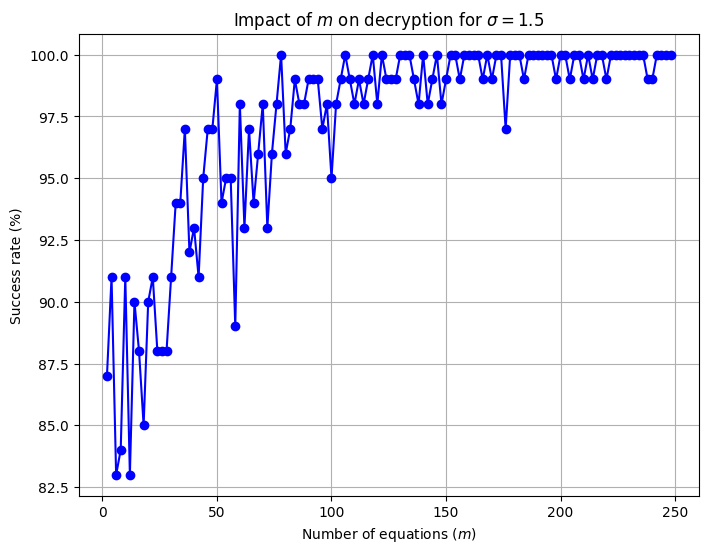

In [16]:
sigma = 1.5
n, q = 2, 11

m_list = np.arange(2, 250, 2)
global_rates_m = []

#We loop over each m
for m in m_list:
  success = 0

  for i in range(100):
      A = rng.integers(0, q, size=(m, n))
      s = rng.integers(0, q, size=n)

      msg = rng.integers(0, 2)

      b = encrypt_LWE(msg, sigma, A, s, m, q)

      v, m_decrypted = decrypt_LWE(b, A, s, q)

      if msg == m_decrypted :
        success += 1
  rate = (success/100)*100
  global_rates_m.append(rate)

plt.figure(figsize=(8, 6))
plt.plot(m_list, global_rates_m, color="blue", marker="o")
plt.xlabel(r"Number of equations ($m$)")
plt.ylabel(r"Success rate (%)")
plt.title(r"Impact of $m$ on decryption for $\sigma =$" + f"{sigma}")
plt.grid(True)
plt.show()



### Results and interpretation
**Observation:**

The curve shows a clear phase transition as a function of $m$. For a small number of equations ($m < 25$), the success rate is unstable and has large variations.

As $m$ increases, the decryption rate increases monotonically. From $m = 150$, the fluctuations fade and the success rate stabilizes at $1.00$ (100 %).

**Mathematical interpretation:** This behavior empirically validates the Law of Large Numbers (LLN) applied to noise smoothing.

Let $\bar{E} = \frac{1}{m}\sum_{i=1}^{m} e_i$ be the empirical mean of the noise. Each elementary error follows a centered discrete Gaussian distribution: $\mathbb{E}[e_i] = 0$ and $\text{Var}(e_i) = \sigma^2$.

$m < 25$: The sample is too small. The sampling variance is maximal:

$$\text{Var}(\bar{E}) = \frac{\sigma^2}{m}$$

The noises of some simulations have extreme fluctuations that cross the critical geometric decision threshold ($\lfloor q/4 \rfloor = 25$).

This causes decoding errors and the chaotic behavior of the curve. Asymptotic regime ($m \ge 150$):
When $m$ grows, the LLN ensures that the variance of the mean converges to 0:

$$\lim_{m \to \infty} \text{Var}(\bar{E}) = 0$$

For $m = 150$ with $\sigma = 1.5$, the spread of the noise is reduced enough so that no simulation exceeds the critical threshold.

The system becomes statistically robust and guarantees perfect decryption ($1.00$).

## 4.4 Impact of n (the dimension of the secret)

In this section, we are going to study the size of $n$. $n$ is the main **security parameter**: the larger $n$ is, the longer the secret $s$ is, and the harder the system is to attack for a computer (or a quantum computer).

Let's start by testing 2 values of $n$, $n = 1$, $n = 250$:

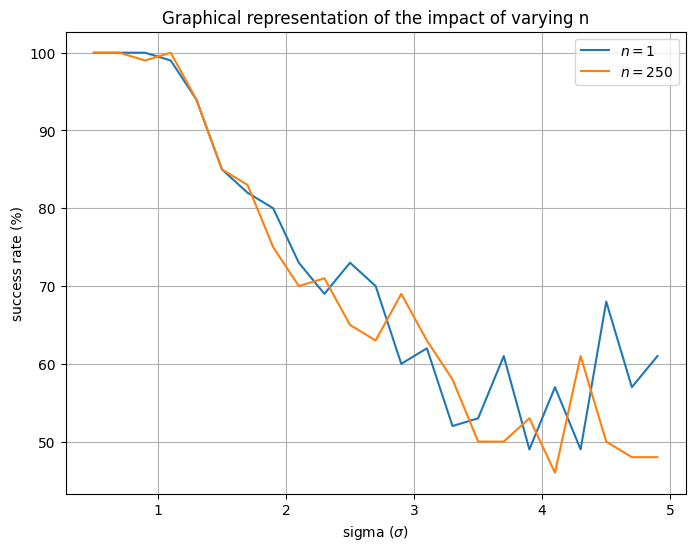

In [17]:
m, q = 10, 11
n_list = [1, 250]
x = np.arange(0.5, 5.0, 0.2) #the values of sigma

plt.figure(figsize=(8, 6))

for n in n_list:
  plt.plot(x, phase_transition_study(n, m, q, x), label=f"$n={n}$")

plt.legend()
plt.xlabel(r"sigma ($\sigma$)")
plt.ylabel(r"success rate (%)")
plt.grid(True)
plt.title("Graphical representation of the impact of varying n")
plt.show()




### Results and Interpretation

**Observation:**
We see on the graph that the curves for $n = 1$ and $n = 250$ overlap almost perfectly. Unlike $m$, varying the dimension of the secret $n$ in an extreme way does not change the decryption phase transition.

**Why?**

This behavior is explained by the analytical study of the protocol. During the decryption phase, the user computes for each equation $i$: $$v_i = b_i - A_i \cdot s \pmod q$$

By substituting the encryption formula $b_i = A_i \cdot s + e_i + msg \cdot \lfloor q/2 \rfloor$,

we get: $$v_i = (A_i \cdot s + e_i + msg \cdot \lfloor q/2 \rfloor) - A_i \cdot s \equiv e_i + msg \cdot \lfloor q/2 \rfloor \pmod q$$

This equality shows that the signal received after correction ($v_i$) depends only on the initial message and on the noise $e_i$ alone. The dimension $n$ (the number of columns of $A$) and the secret $s$ cancel out.

Since the noise $e_i \sim \mathcal{N}(0, \sigma^2)$ is sampled independently of $n$, the decoding error probability per row is mathematically invariant with respect to $n$.

**Conclusion:** The dimension $n$ has no impact on the reliability of decryption for the legitimate user.
Increasing it only serves to guarantee the security of the encryption by increasing the complexity of searching for the secret $s$ for an attacker.

### Complexity and Security against the attacker

**The attacker's problem: Searching for the target**

The attacker intercepts the public pair $(A, b) \in \mathbb{Z}_q^{m \times n} \times \mathbb{Z}_q^m$. Their goal is to find the unique secret $s \in \mathbb{Z}_q^n$. They know that:
$$b = A \cdot s + e \pmod q$$

If there were no noise ($e = 0$), the attacker would solve the system by Gaussian elimination with complexity $\mathcal{O}(m \cdot n^2)$.

However, because of the noise $e$, each row $i$ of the system has a small unknown error $e_i \in \{-\lfloor q/4 \rfloor, \dots, \lfloor q/4 \rfloor\}$. Trying classical Gaussian elimination will combine and multiply these errors linearly, making the system of equations wrong.

**The Brute Force attack**

The brute force attack consists in testing all possible candidate vectors $s'$ in the key space.

- The space of secrets is the vector set $\mathbb{Z}_q^n$.
- The number of possible secrets (the cardinality of the space) is given by: $$\text{Number of possible keys} = q^n$$

For each candidate $s'$, the attacker must compute the residual vector $e' = b - A \cdot s' \pmod q$. If the components of $e'$ follow a Gaussian distribution close to 0, they have found the right secret.

The time complexity of this search is of the form: $$\mathcal{O}(n \cdot m \cdot q^n)$$

The impact of the dimension $n$ is **exponential** here. For example:
- With $n = 2$ and $q = 11$, the attacker has $11^2 = 121$ operations to do.
- With $n = 250$ and $q = 11$, the complexity is of the order of $11^{250} \approx 10^{260}$ operations. This number is far larger than the number of atoms in the observable universe ($\approx 10^{80}$).

So the brute force attack is not a possible method as soon as $n$ takes large values.

### Impact of q (modulus)

The idea is to understand how the size of $q$ affects decryption.

**The mathematical intuition:**

The noise $\sigma$ "eats into" the space of the modulus $q$.

- If $q$ is very small (such as $q = 11$), a noise of $\sigma = 2$ is huge because it represents a large part of the available space before reaching the error threshold ($\approx q/4$)

- If $q$ is very large (for example $q = 997$), a noise of $\sigma = 2$ becomes tiny and insignificant compared to the size of the modulus.

We therefore expect that increasing $q$ **makes decryption much more robust and tolerant to larger noises**.

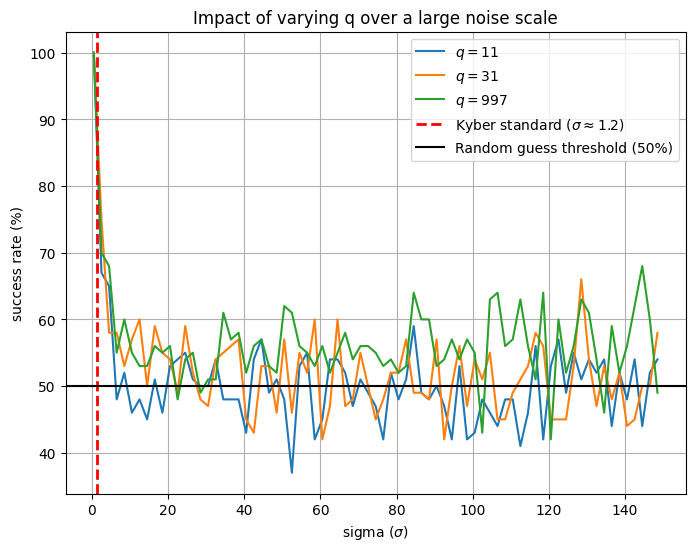

In [18]:
m, n = 10, 2
q_list = [11, 31, 997]
x = np.arange(0.5, 150.0, 2.0) #the values of sigma

plt.figure(figsize=(8, 6))

for q in q_list:
  plt.plot(x, phase_transition_study(n, m, q, x), label=f"$q={q}$")

plt.axvline(x=1.2, color='red', linestyle='--', linewidth=2, label=r'Kyber standard ($\sigma \approx 1.2$)')
plt.axhline(y=50, color='black', label='Random guess threshold (50%)')

plt.legend()
plt.xlabel(r"sigma ($\sigma$)")
plt.ylabel(r"success rate (%)")
plt.grid(True)
plt.title("Impact of varying q over a large noise scale")
plt.show()

### Impact of the modulus $q$ on noise tolerance

**Observation:**
On this large-scale graph, we clearly see that the size of the modulus q determines how fast the success rate degrades as the noise ($\sigma$) increases.

- For $q = 11$, the curve collapses instantly at the very beginning of the graph (stuck to the left).

- For $q = 101$, the system tolerates a bit more noise before dropping in the middle of the graph.

- For $q = 997$, the success rate stays perfect (100%) over a very long range of noise before finally going down much further to the right.

The larger the modulus $q$ is, the more the phase transition is shifted to the right, which means that the system tolerates much higher noise values.

This difference in behavior is explained by the geometry of decoding in the space $\mathbb{Z}_q$. During the decryption phase, the maximum theoretical noise tolerance (the decision threshold to distinguish one message from another) is directly proportional to the size of the modulus. It is set by the rule: $$ \text{Tolerance threshold} = \lfloor q/4 \rfloor$$

For a given point on the x-axis, the absolute error $e_i$ added is statistically the same for the three configurations. However:

- For $q = 11$, the threshold is $\lfloor 11/4 \rfloor = 2$. A noise greater than 2 immediately saturates the available space and causes failure.

- For $q = 101$, the threshold goes up to $\lfloor 101/4 \rfloor = 25$.

- For $q = 997$, the threshold reaches $\lfloor 997/4 \rfloor = 249$. An error of size 10 or 20, which was fatal for $q=11$, is insignificant here compared to the available margin of 249.

**Conclusion:**
Increasing the modulus $q$ widens the decision zones during decryption, which guarantees excellent reliability for the legitimate user.

### Cross analysis and interaction ($m$ and $\sigma$)

Until now, we have studied the impact of the parameters $m$, $n$ and $q$ in a completely isolated way, by arbitrarily fixing the other variables. In a real scenario, these parameters coexist and influence each other.

The goal of this section is to do a two-dimensional cross analysis to observe how the number of available equations ($m$) interacts directly with the intensity of the noise ($\sigma$).

To do this, we are going to generate a Heatmap. The principle is to map the decryption success rate (represented by a color gradient from red to green) on a grid where each cell corresponds to a unique pair ($m, \sigma$).

**Expected behavior (Hypothesis)**:
Based on the results obtained previously, we expect:

- Increasing the standard deviation $\sigma$ adds stronger perturbations, which tends to push the system toward failure (success rate at 50%).

- Increasing the number of equations $m$ lets the law of large numbers act, which tends to stabilize the system (success rate at 100%).



In [19]:
import seaborn as sns

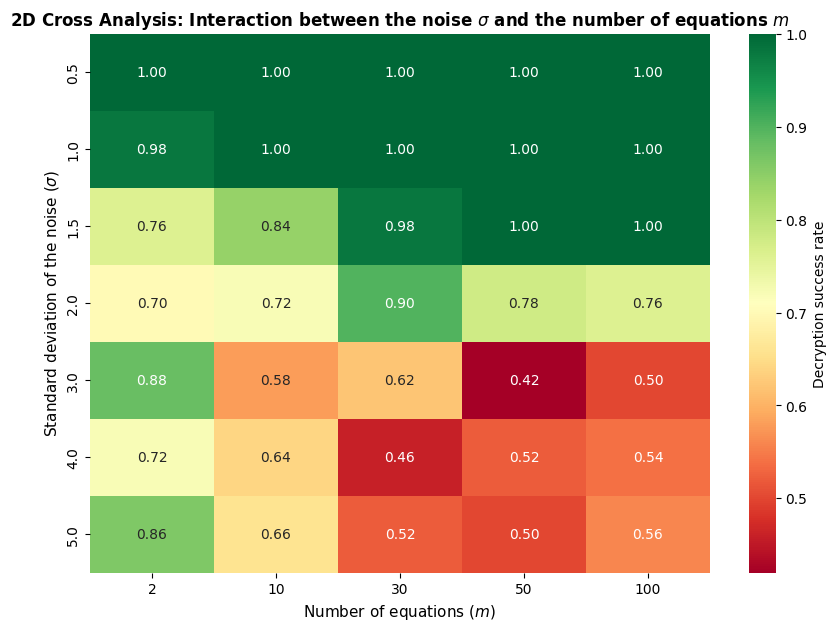

In [20]:
ms = [2, 10, 30, 50, 100]
sigmas = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]

n, q = 10, 101
nb_tests = 50

#we create a matrix of 0 with the right dimensions
#rows = nb of sigmas and columns = nb of m

matrix = np.zeros((len(sigmas), len(ms)))

#double nested loop

for i, sigma in enumerate(sigmas):
  for j, m in enumerate(ms):
    success = 0
    for a in range(nb_tests):

      #Mini LWE simulation
      msg = np.random.randint(0,2)
      A = rng.integers(0, q, size=(m, n))
      s = rng.integers(0, q, size=n)

      b = encrypt_LWE(msg, sigma, A, s, m, q)

      _, msg_found = decrypt_LWE(b, A, s, q)

      if msg_found == msg:
        success +=1
    matrix[i, j] = success /nb_tests

#The Heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    matrix,
    annot = True,
    fmt=".2f",
    cmap="RdYlGn", #red to yellow to green
    xticklabels=ms,
    yticklabels=sigmas,
    cbar_kws={'label': 'Decryption success rate'}
)

plt.title(r"2D Cross Analysis: Interaction between the noise $\sigma$ and the number of equations $m$", fontsize=12, fontweight="bold")
plt.xlabel(r"Number of equations ($m$)", fontsize=11)
plt.ylabel(r"Standard deviation of the noise ($\sigma$)", fontsize=11)

plt.grid(False)
plt.show()




**Explanations**
The critical error tolerance threshold is defined by:

$$Threshold = \lfloor q/4 \rfloor = \lfloor 101/4 \rfloor = 25$$

During decryption, the algorithm computes a centered mean residual $\bar{E}$ and applies the binary rule:

- $\text{If } |\bar{E}| \le 25 \implies \text{Message} = 0 \quad (\text{Acceptance zone of size } 51)$
- $\text{If } |\bar{E}| > 25 \implies \text{Message} = 1 \quad (\text{Acceptance zone of size } 50)$

Each message therefore takes **50%** of the total space of the modular circle.

**Case $m = 100$**:

Each row has an initial noise $e_i \sim \mathcal{N}(0, \sigma^2)$. For $\sigma = 4.0$, the noise accumulated by the computations saturates the space and destroys the information. According to the **Law of Large Numbers**, the mean of our 100 equations converges to the real distribution of the system, which has become uniform.

The computation of the theoretical success rate under a uniform distribution is the ratio of favorable cases to total cases:

$$\text{Rate}_{m=100} = \frac{\text{Size of Message } 0 \text{ zone}}{\text{Total size of } \mathbb{Z}_{101}} = \frac{51}{101} \approx 0.5049$$

At $\sigma = 4.0$, the noise is so strong that it erases the message. Since there are many equations ($m = 100$), the statistics are reliable and confirm that there is no signal left.
The algorithm guesses at random. In binary, chance gives a success rate of **50%**

**Case $m = 2$**

According to the **Central Limit Theorem**, the variance of a sample is inversely proportional to its size: $Var(\bar E) = \frac{\sigma^2}{m}$.

- For $m = 100 \implies \text{Var}(\bar{E}) = \frac{16}{100} = 0.16$

- For $m = 2 \implies Var(\bar E) = \frac{16}{2} = 8$

Taking only $m = 2$ equations is a sample too small for the mean to stabilize. By pure chance, the large noises of the two rows sometimes cancel out, giving a mean of 0.

The algorithm validates the answer; the score of 0.75 is a **statistical illusion** due to the lack of rows, and not a sign of reliability.

**Conclusion:**

Increasing the number of equations ($m$) smooths the noise, but the Law of Large Numbers cannot save anything if the initial noise $\sigma$ has already saturated the modulus $q$. To avoid the red zone (0.50), **Kyber** mathematically chooses a huge modulus ($q = 3329$) and a small noise ($\sigma = 1.2$)

# Part 5: Summary, Perspectives and Outlook

## 5.1 Comparison RSA vs LWE

| Criterion | RSA (Classical algebraic approach) | LWE (Post-quantum geometric approach) |
| :--- | :--- | :--- |
| **The mathematical problem** | **Factorization in the ring $\mathbb{Z}/n\mathbb{Z}$.**<br><br>Security relies on the computational difficulty of finding two large prime factors $p$ and $q$ from their product $n = p \cdot q$.<br><br>It is a one-dimensional problem based on modular arithmetic. | **Decoding perturbed linear codes.**<br><br>The secret is hidden in a vector space of high dimension $n$.<br><br>We build a system of linear matrix equations to which we add a random "noise" from a discrete Gaussian distribution ($b = As + e$). |
| **Resistance to quantum computing** | **Total vulnerability.**<br><br>Shor's algorithm uses the Quantum Fourier Transform to find the period of the modular exponentiation function in polynomial time.<br><br>The search space collapses. | **Algorithmic immunity.**<br><br>There is no known quantum algorithm able to efficiently solve the shortest vector problem (SVP) or to find the original point when the system is perturbed by noise. |
| **Computational complexity** | **Computationally expensive (Asymptotic).**<br><br>Encryption requires modular exponentiation operations on integers of several thousand bits.<br><br>This requires significant CPU power to handle these large numbers. | **Simple linear algebra algorithm.**<br><br>The basic operations come down to matrix-vector products and vector additions in $\mathbb{Z}/q\mathbb{Z}$.<br><br>The computational cost is minimal for machines. |

## 5.2 What I learned throughout this Notebook

This project allowed me to understand in a concrete way the transition to post-quantum cryptography.
Through the implementation and the manipulation of the parameters ($n, m, q, \sigma$), I understood that the computer security of tomorrow relies on the statistical and geometric control of a noise.

The analysis of the phase transition allowed me to understand the choice behind the parameters, especially their impact on robustness against the attacker, and reliability for the legitimate user.

## 5.3 Outlook on Kyber/ML-KEM

The standard LWE algorithm that we studied has a major drawback in practice: the size of the public matrix $A \in {Z}_q^{m \times n}$ grows quadratically, which turns out to be too heavy for real network architectures (memory, bandwidth).

To solve this problem, the global standard **ML-KEM** (also known as Kyber), selected by NIST in 2022 to replace RSA, uses a variant called **Module-LWE (ML-LWE).**

Instead of using integers in the matrix A, Kyber uses **polynomials** in a cyclotomic ring:

$$R_q = \mathbb{Z}_q[X]/(X^{256} + 1)$$

The algorithmic advantage is that a matrix of polynomials makes it possible to greatly compress the size of public keys.

Regarding the choice of parameters: Kyber fixes a very small modulus, $q = 3329$, and uses the Number Theoretic Transform (NTT) to multiply polynomials in time $\mathcal{O}(d \log d)$.

And regarding error management: just like our simulation, Kyber has a non-zero theoretical decryption failure rate, but it is mathematically bounded to be lower than $2^{-139}$ (a risk lower than seeing a meteorite destroy the Earth at the same moment).

# References

1. **Regev, O. (2005).** *On lattices, learning with errors, random linear codes, and cryptography.* Journal of the ACM (JACM), 56(6), 1-40. (The founding paper that introduced the LWE problem and its security reduction).
2. **Laguillaumie, F., Langlois, A., & Stehlé, D. (2014).** *Chiffrement avancé à partir du problème Learning With Errors.* HAL open science. [Online] https://inria.hal.science/hal-00984055v1/document (An excellent reference resource in French detailing advanced constructions around LWE).
3. **Shor, P. W. (1994).** *Algorithms for quantum computation: discrete logarithms and factoring.* IEEE. (The historical proof of the vulnerability of RSA and the discrete logarithm to quantum computing).
4. **Micciancio, D. (2020).** *The Learning With Errors Problem (LWE).* UC San Diego (CSE 208). [Lecture slides] https://cseweb.ucsd.edu/classes/fa20/cse208-a/lwe.pdf (Very clear university course material covering the geometric and algorithmic aspects of LWE).
5. **NIST (2024).** *FIPS 203: Module-Lattice-Based Key-Encapsulation Mechanism Standard.* (The official document setting the global industrial specifications of ML-KEM / Kyber).
6. **Wikipedia contributors (2024).** *Apprentissage avec erreurs.* Wikipédia, l'encyclopédie libre. [Online] https://fr.wikipedia.org/wiki/Apprentissage_avec_erreurs (A rigorous and accessible introduction in French).
7. **Roetteler, M., Naehrig, M., Svore, K. M., & Vasudevan, C. (2017).** *Quantum resource estimates for computing elliptic curve discrete logarithms.* (Evaluation and quantification of the quantum resources needed for the cryptographic transition).